
# BV2 A03 – MNIST Klassifikations-Test & Pixel-Inversion

Dieses Notebook lädt ein trainiertes CNN, klassifiziert alle **Trainingsbilder** des MNIST-Datensatzes
und führt (für **korrekt** klassifizierte Bilder) einen **Pixel-für-Pixel-Inversions-Test** durch:
für jeden der 28×28 Bildpunkte wird der Wert in **Rohwerten** invertiert: \( f(a) = 1 - a \).

**Wichtig:** Wenn dein Modell mit Normalisierung (z. B. MNIST-Mean/Std) trainiert wurde, wenden wir
die Inversion **vor** der Normalisierung an, und normalisieren **danach** für die Vorhersage.
So bleibt die Aufgabenstellung (Invertieren in [0,1]) erfüllt **und** das Modell sieht die
gewohnten normalisierten Eingaben.


In [75]:

import os, math, random, json
from dataclasses import dataclass
from time import time
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

# ---------- Repro & Device ----------
def set_seed(s=42):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

set_seed(42)

DEVICE = (
    "mps" if torch.backends.mps.is_available()
    else ("cuda" if torch.cuda.is_available() else "cpu")
)
print("Using device:", DEVICE)

# ---------- Pfade & Parameter ----------
# Passe den Pfad zu deinen Gewichten an, falls sie anders heißen/liegen.
MODEL_PATH = "mnist_cnn_state_dict.pt"  # z.B. aus deinem Trainings-Notebook
DATA_DIR   = "./data"

# Laufzeit-Optionen (für schnellere Testläufe anfangs begrenzen)
MAX_ATTACK_SAMPLES = 50     # None = alle korrekten Trainingsbilder untersuchen
ATTACK_ONLY_CLASS  = None     # z.B. 3 -> nur Klasse '3' analysieren
REPORT_TOPK        = 20       # Top-K Confusion-Paare

# Wenn dein Training OHNE Normalize lief: setze USE_NORMALIZE=False
USE_NORMALIZE      = True
MNIST_MEAN, MNIST_STD = (0.1307,), (0.3081,)


Using device: mps


In [76]:

# ---------- Modell-Definition: muss zur Trainings-Architektur passen ----------
class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)  # Logits
        return x

def load_model(model_path=MODEL_PATH, device=DEVICE):
    model = SmallCNN().to(device)
    state = torch.load(model_path, map_location=device)
    model.load_state_dict(state)
    model.eval()
    print(f"Loaded weights from: {model_path}")
    return model


In [77]:

# ---------- Datensatz & Loader ----------
# Wir halten zwei Pipelines bereit:
# - raw_tf: ToTensor() -> Rohwerte in [0,1] (für das Invertieren)
# - norm_tf: ToTensor()+Normalize(...) ODER nur ToTensor(), je nachdem wie trainiert wurde
raw_tf  = transforms.ToTensor()

if USE_NORMALIZE:
    norm_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MNIST_MEAN, MNIST_STD),
    ])
else:
    norm_tf = transforms.ToTensor()

# Fürs Laden der Trainingsbilder als Rohwerte:
train_ds_raw = datasets.MNIST(DATA_DIR, train=True, download=True, transform=raw_tf)

# Fürs direkte Evaluieren/Smoke-Test (optional):
train_ds_norm = datasets.MNIST(DATA_DIR, train=True, download=True, transform=norm_tf)

# DataLoader für Angriff: batch_size=1, num_workers=0 (Notebook/macOS-freundlich)
attack_loader = DataLoader(train_ds_raw, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)
eval_loader   = DataLoader(train_ds_norm, batch_size=256, shuffle=False, num_workers=0, pin_memory=False)

print("Train size:", len(train_ds_raw))


Train size: 60000


In [78]:

# ---------- Hilfsfunktionen ----------
@torch.no_grad()
def predict_label(model, img_tensor_norm, device=DEVICE):
    # img_tensor_norm: [1,1,28,28] bereits NORMALISIERT, falls USE_NORMALIZE=True
    logits = model(img_tensor_norm.to(device))
    return logits.argmax(dim=1).item()

def to_normalized(img_tensor_raw):
    # img_tensor_raw: [1,1,28,28] in [0,1]
    if USE_NORMALIZE:
        # transform Compose erwartet [C,H,W] -> für einzelne Batches wenden wir manuell an:
        # (x - mean) / std  elementweise
        mean = torch.tensor(MNIST_MEAN, dtype=img_tensor_raw.dtype, device=img_tensor_raw.device).view(1,-1,1,1)
        std  = torch.tensor(MNIST_STD,  dtype=img_tensor_raw.dtype, device=img_tensor_raw.device).view(1,-1,1,1)
        return (img_tensor_raw - mean) / std
    else:
        return img_tensor_raw

def invert_single_pixel(img_raw_1chw, i, j):
    # img_raw_1chw: [1,1,28,28] in [0,1]
    x = img_raw_1chw.clone()
    x[0, 0, i, j] = 1.0 - x[0, 0, i, j]
    return x

@torch.no_grad()
def evaluate(model, loader, device=DEVICE):
    model.eval()
    correct=0; total=0
    for x,y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        preds = logits.argmax(1)
        correct += (preds==y).sum().item()
        total += y.size(0)
    return correct/total


In [79]:

# ---------- Modell laden & kurzer Smoke-Test ----------
model = load_model(MODEL_PATH, DEVICE)
acc_train = evaluate(model, eval_loader, DEVICE)
print(f"Train-Accuracy (mit normierten Daten): {acc_train*100:.2f}%")


Loaded weights from: mnist_cnn_state_dict.pt
Train-Accuracy (mit normierten Daten): 98.63%


In [80]:

# ---------- Pixel-Inversions-Angriff ----------
t0 = time()

# Indizes ggf. filtern (Klasse & Max Samples)
indices = list(range(len(train_ds_raw)))
if ATTACK_ONLY_CLASS is not None:
    indices = [i for i in indices if train_ds_raw[i][1] == ATTACK_ONLY_CLASS]
if MAX_ATTACK_SAMPLES is not None:
    indices = indices[:MAX_ATTACK_SAMPLES]

# Statistik
attackable = 0
robust     = 0
total_considered = 0
confusions = Counter()          # (true, predicted_after_flip) -> count
heatmap    = np.zeros((28,28), dtype=np.int64)

false_preds = []

for idx in indices:
    img_raw, label = train_ds_raw[idx]               # img_raw: [1,28,28] in [0,1]
    img_raw = img_raw.unsqueeze(0)                   # [1,1,28,28]
    label   = int(label)

    # Vorhersage auf dem UNVERÄNDERTEN Bild (nach Normalisierung)
    img_norm = to_normalized(img_raw.clone()).to(DEVICE)
    pred0 = predict_label(model, img_norm)
    if pred0 != label:
        print(f"Incorrect prediction {pred0} for label {label} at index {idx}")

        continue  # nur korrekt klassifizierte betrachten

    total_considered += 1
    flipped_makes_wrong = False

    # Alle 28x28 Pixel invertieren:
    for i in range(28):
        for j in range(28):
            x_flip_raw  = invert_single_pixel(img_raw, i, j)       # invert in [0,1]
            x_flip_norm = to_normalized(x_flip_raw).to(DEVICE)     # dann normalisieren
            pred = predict_label(model, x_flip_norm)
            if pred != label:
                flipped_makes_wrong = True
                confusions[(label, pred)] += 1
                heatmap[i, j] += 1

    if flipped_makes_wrong:
        attackable += 1
    else:
        robust += 1

dt = time() - t0
print(f"Fertig. Dauer: {dt/60:.1f} min bei {len(indices)} Bildern (davon betrachtet: {total_considered}).")
print("Angreifbar:", attackable, "| Robust:", robust)



Fertig. Dauer: 1.0 min bei 50 Bildern (davon betrachtet: 50).
Angreifbar: 3 | Robust: 47


In [81]:

# ---------- Reporting ----------
print("\n=== Zusammenfassung ===")
print(f"Betrachtete (initial korrekt): {total_considered}")
print(f"Angreifbar: {attackable}  ({(attackable/max(total_considered,1))*100:.2f}%)")
print(f"Robust:     {robust}      ({(robust/max(total_considered,1))*100:.2f}%)")

print("\nHäufigste Klassenvertauschungen (true -> predicted):")
for (pair, cnt) in confusions.most_common(REPORT_TOPK):
    print(f"  {pair[0]} -> {pair[1]} : {cnt}")

# Speichern der Ergebnisse
np.save(f"pixel_sensitivity_heatmap{MAX_ATTACK_SAMPLES}samples.npy", heatmap)
with open(f"confusions_counts_{MAX_ATTACK_SAMPLES}samples.json", "w") as f:
    json.dump({f"{a}->{b}": int(c) for (a,b),c in confusions.items()}, f, indent=2)
print("\nGespeichert: pixel_sensitivity_heatmap.npy, confusions_counts.json")



=== Zusammenfassung ===
Betrachtete (initial korrekt): 50
Angreifbar: 3  (6.00%)
Robust:     47      (94.00%)

Häufigste Klassenvertauschungen (true -> predicted):
  7 -> 2 : 131
  5 -> 3 : 15
  7 -> 9 : 8
  9 -> 5 : 8

Gespeichert: pixel_sensitivity_heatmap.npy, confusions_counts.json


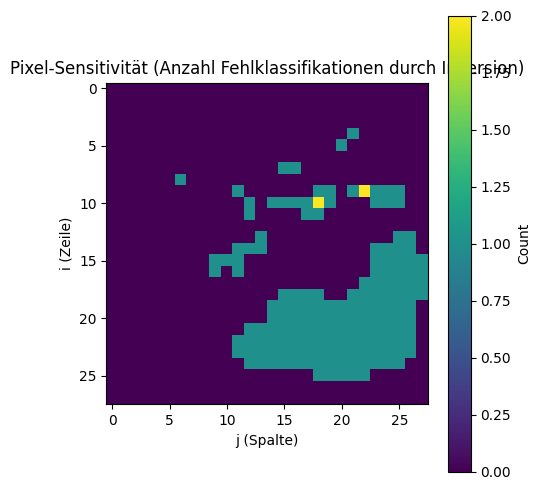

In [82]:

# ---------- Heatmap anzeigen ----------
# Hinweis: Aufgabe verlangt keine bestimmte Farbskala – wir plotten eine einfache Intensitätskarte.
plt.figure(figsize=(5,5))
plt.imshow(heatmap, interpolation='nearest')
plt.title("Pixel-Sensitivität (Anzahl Fehlklassifikationen durch Inversion)")
plt.xlabel("j (Spalte)"); plt.ylabel("i (Zeile)")
plt.colorbar(label="Count")
plt.tight_layout()
plt.show()



## Hinweise zur Laufzeit
- Der Angriff ist **teuer**: pro Bild 784 Forward-Pässe. Beginne mit `MAX_ATTACK_SAMPLES = 300` oder setze `ATTACK_ONLY_CLASS` (z. B. nur Klasse 3), um schneller Ergebnisse zu bekommen.
- Stelle sicher, dass `MODEL_PATH` auf deine **trainierten Gewichte** zeigt.
- Wenn du **ohne** Normalisierung trainiert hast, setze `USE_NORMALIZE=False`.
- Die Heatmap wird als `pixel_sensitivity_heatmap.npy` gespeichert (NumPy-Array) und kann später erneut geladen/visualisiert werden.
